R2 Score: 0.4384266108907896
MSE: 115914303295243.47
Predicted Price (in Rupees): 6488308.852753147


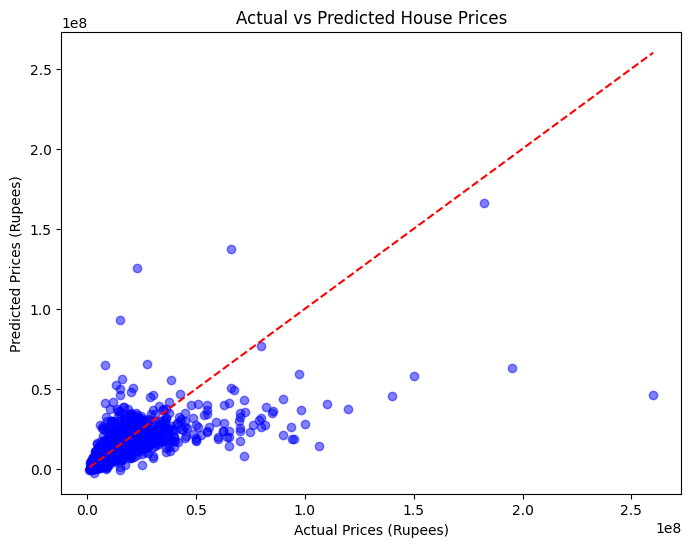

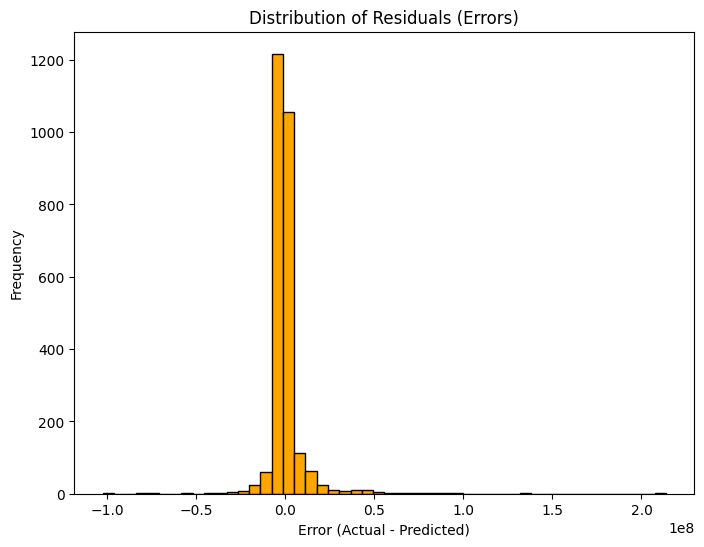

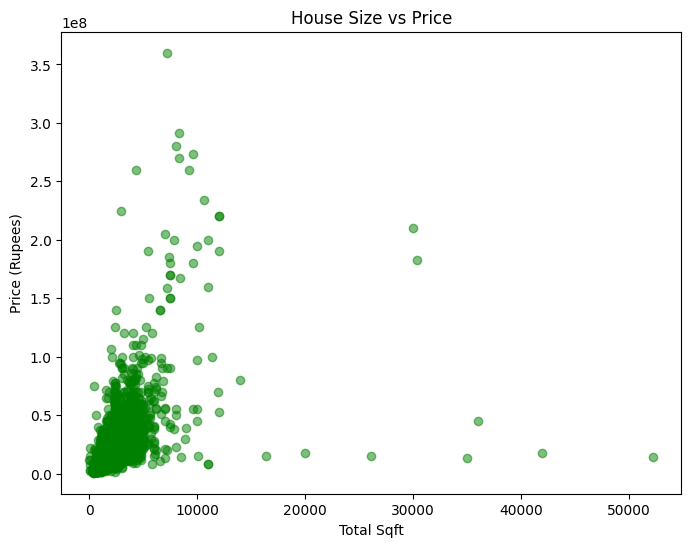

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('bengaluru_house_prices.csv')

# Extract BHK from 'size' column
data['bhk'] = data['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)

# Clean 'total_sqft'
def convert_sqft(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft)

# Drop invalid rows
data = data.dropna(subset=['total_sqft', 'bath', 'bhk', 'price'])

# Features and target
X = data[['total_sqft', 'bath', 'bhk']]
y = data['price'] * 100000   # Convert lakhs to rupees

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Predict a new house
new_house = pd.DataFrame({'total_sqft': [1200], 'bath': [2], 'bhk': [3]})
new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)
print("Predicted Price (in Rupees):", predicted_price[0])

# ---------------- VISUALS ----------------

# 1. Scatter plot of Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel("Actual Prices (Rupees)")
plt.ylabel("Predicted Prices (Rupees)")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()

# 2. Residuals distribution (bar style)
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50, color='orange', edgecolor='black')
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

# 3. Feature vs Price (example: sqft vs price)
plt.figure(figsize=(8,6))
plt.scatter(data['total_sqft'], data['price']*100000, alpha=0.5, color='green')
plt.title("House Size vs Price")
plt.xlabel("Total Sqft")
plt.ylabel("Price (Rupees)")
plt.show()


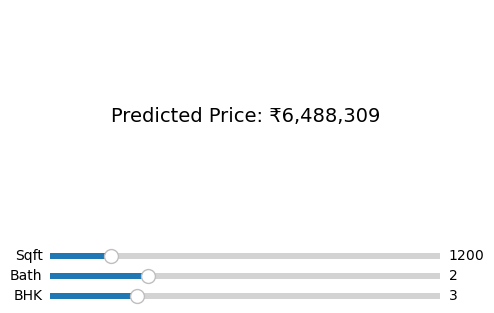

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('bengaluru_house_prices.csv')

# Extract BHK from 'size' column
data['bhk'] = data['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)

# Clean 'total_sqft'
def convert_sqft(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft)

# Drop invalid rows
data = data.dropna(subset=['total_sqft', 'bath', 'bhk', 'price'])

# Features and target
X = data[['total_sqft', 'bath', 'bhk']]
y = data['price'] * 100000   # Convert lakhs to rupees

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# --- Interactive sliders with matplotlib ---
# Initial values
init_sqft = 1200
init_bath = 2
init_bhk = 3

# Create figure
fig, ax = plt.subplots(figsize=(6,4))
plt.subplots_adjust(left=0.25, bottom=0.35)
ax.set_axis_off()

# Function to predict price
def predict_price(sqft, bath, bhk):
    new_house = pd.DataFrame({'total_sqft':[sqft], 'bath':[bath], 'bhk':[bhk]})
    new_house_scaled = scaler.transform(new_house)
    return model.predict(new_house_scaled)[0]

# Initial prediction
pred = predict_price(init_sqft, init_bath, init_bhk)
text_display = ax.text(0.5, 0.5, f"Predicted Price: ₹{pred:,.0f}", 
                       ha='center', va='center', fontsize=14)

# Slider axes
ax_sqft = plt.axes([0.25, 0.25, 0.65, 0.03])
ax_bath = plt.axes([0.25, 0.20, 0.65, 0.03])
ax_bhk  = plt.axes([0.25, 0.15, 0.65, 0.03])

sqft_slider = Slider(ax_sqft, 'Sqft', 500, 5000, valinit=init_sqft, valstep=100)
bath_slider = Slider(ax_bath, 'Bath', 1, 5, valinit=init_bath, valstep=1)
bhk_slider  = Slider(ax_bhk, 'BHK', 1, 10, valinit=init_bhk, valstep=1)

# Update function
def update(val):
    sqft = sqft_slider.val
    bath = bath_slider.val
    bhk  = bhk_slider.val
    pred = predict_price(sqft, bath, bhk)
    text_display.set_text(f"Predicted Price: ₹{pred:,.0f}")
    fig.canvas.draw_idle()

# Connect sliders
sqft_slider.on_changed(update)
bath_slider.on_changed(update)
bhk_slider.on_changed(update)

plt.show()


In [17]:
pip install ipywidgets

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import ipywidgets as widgets
from IPython.display import display

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from IPython.display import display

# Load dataset
data = pd.read_csv('bengaluru_house_prices.csv')

# Extract BHK from 'size' column
data['bhk'] = data['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)

# Clean 'total_sqft'
def convert_sqft(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft)

# Drop invalid rows
data = data.dropna(subset=['total_sqft', 'bath', 'bhk', 'price'])

# Features and target
X = data[['total_sqft', 'bath', 'bhk']]
y = data['price'] * 100000   # Convert lakhs to rupees

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# --- Interactive Widgets ---
sqft_slider = widgets.IntSlider(value=1200, min=500, max=5000, step=100, description="Sqft")
bath_slider = widgets.IntSlider(value=2, min=1, max=5, step=1, description="Bath")
bhk_slider = widgets.IntSlider(value=3, min=1, max=10, step=1, description="BHK")

output = widgets.Output()

def predict_price(change=None):
    with output:
        output.clear_output()
        new_house = pd.DataFrame({
            'total_sqft': [sqft_slider.value],
            'bath': [bath_slider.value],
            'bhk': [bhk_slider.value]
        })
        new_house_scaled = scaler.transform(new_house)
        predicted_price = model.predict(new_house_scaled)[0]
        print(f"Predicted Price: ₹{predicted_price:,.0f}")

# Attach prediction function to slider changes
sqft_slider.observe(predict_price, names='value')
bath_slider.observe(predict_price, names='value')
bhk_slider.observe(predict_price, names='value')

# Display widgets
display(sqft_slider, bath_slider, bhk_slider, output)

# Initial prediction
predict_price()

IntSlider(value=1200, description='Sqft', max=5000, min=500, step=100)

IntSlider(value=2, description='Bath', max=5, min=1)

IntSlider(value=3, description='BHK', max=10, min=1)

Output()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# --- Load and clean dataset ---
data = pd.read_csv('bengaluru_house_prices.csv')
data['bhk'] = data['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else None)

def convert_sqft(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft)
data = data.dropna(subset=['total_sqft','bath','bhk','price'])

X = data[['total_sqft','bath','bhk']]
y = data['price'] * 100000   # convert lakhs to rupees

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)

# --- Dashboard widgets ---
sqft_slider = widgets.IntSlider(value=1200,min=500,max=5000,step=100,description="Sqft",style={'description_width':'initial'})
bath_slider = widgets.IntSlider(value=2,min=1,max=5,step=1,description="Bath",style={'description_width':'initial'})
bhk_slider = widgets.IntSlider(value=3,min=1,max=10,step=1,description="BHK",style={'description_width':'initial'})
location_dropdown = widgets.Dropdown(options=sorted(data['location'].dropna().unique()[:20]),description="Location")
predict_button = widgets.Button(description="Predict Price",button_style='success')
reset_button = widgets.Button(description="Reset",button_style='warning')

output = widgets.Output()

def update_dashboard(change=None):
    with output:
        clear_output(wait=True)
        # Predict price
        new_house = pd.DataFrame({
            'total_sqft':[sqft_slider.value],
            'bath':[bath_slider.value],
            'bhk':[bhk_slider.value]
        })
        new_house_scaled = scaler.transform(new_house)
        predicted_price = model.predict(new_house_scaled)[0]

        print(f"🏡 Location: {location_dropdown.value}")
        print(f"📊 Predicted Price: ₹{predicted_price:,.0f}")

        # --- Visuals ---
        fig, ax = plt.subplots(1,3,figsize=(15,4))

        # Bar chart of selected features
        features = ['Sqft','Bath','BHK']
        values = [sqft_slider.value,bath_slider.value,bhk_slider.value]
        ax[0].bar(features,values,color=['skyblue','orange','green'])
        ax[0].set_title("Selected House Features")

        # Pie chart of feature proportions
        ax[1].pie(values,labels=features,autopct='%1.1f%%',
                  colors=['skyblue','orange','green'],startangle=90)
        ax[1].set_title("Feature Proportions")

        # Price distribution chart
        ax[2].hist(data['price']*100000,bins=30,color='purple',alpha=0.7)
        ax[2].set_title("Dataset Price Distribution")
        ax[2].set_xlabel("Price (Rupees)")
        ax[2].set_ylabel("Count")

        plt.show()

def reset_dashboard(change=None):
    sqft_slider.value = 1200
    bath_slider.value = 2
    bhk_slider.value = 3
    location_dropdown.value = location_dropdown.options[0]
    update_dashboard()

# Attach functions
predict_button.on_click(update_dashboard)
reset_button.on_click(reset_dashboard)

# Display dashboard
dashboard = widgets.VBox([
    widgets.HBox([sqft_slider,bath_slider,bhk_slider]),
    location_dropdown,
    widgets.HBox([predict_button,reset_button]),
    output
])
display(dashboard)

# Initial run
update_dashboard()
